In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
parent_dir = os.path.dirname(os.environ["GTE_DIR"].replace("Glaciation_time_estimator",""))
GTE_DIR=os.environ["GTE_DIR"]
sys.path.insert(0, parent_dir)
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [2]:
config = read_config(
    os.path.join(GTE_DIR,'config_half.yaml'))
analyze_year=True
year=2022
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']

In [ ]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    else:
        return 'SON'
if os.uname()[1]=="n2o":
    combined_cloud_df = pd.read_parquet(f"/wolke_scratch/dnikolo/Final_results/{year}_all.parquet")
    glaciations_df = pd.read_parquet(f"/wolke_scratch/dnikolo/Final_results/{year}_glac_04.parquet")
if os.uname()[1][:3]=="eu-":
    combined_cloud_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/full_years/{year}_all.parquet")
    glaciations_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/full_years/{year}_glac_04_thresh.parquet") #_{int(glac_threshold*10):02}_thresh

combined_cloud_df=combined_cloud_df[~combined_cloud_df.is_large_pix_cloud]
combined_cloud_df = combined_cloud_df[(combined_cloud_df.avg_lat >30) | (combined_cloud_df.avg_lat<-30)]

glaciations_df=glaciations_df[~glaciations_df.is_large_pix_cloud]
glaciations_df = glaciations_df[(glaciations_df.avg_lat >30) | (glaciations_df.avg_lat<-30)]


combined_cloud_df['Season'] = combined_cloud_df['track_start_time'].dt.month.apply(month_to_season)
glaciations_df["Radius [km]"]=np.sqrt(glaciations_df["avg_size[km]"]/np.pi)
glaciations_df['Season'] = glaciations_df['track_start_time'].dt.month.apply(month_to_season)
glaciating_clouds = glaciations_df.drop_duplicates(subset="Cloud_ID",keep="first")
combined_cloud_df['is_glaciating'] = combined_cloud_df.index.isin(glaciating_clouds['Cloud_ID'])
combined_cloud_df["month"]= pd.to_datetime(combined_cloud_df['track_start_time']).dt.month
assert glaciating_clouds["Cloud_ID"].isin(combined_cloud_df.index).all(),"The files don't correspont to each other"

In [4]:
len(combined_cloud_df)

3293891

In [5]:
(combined_cloud_df["month"]==0).sum()

0

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(1.0, 12.0)

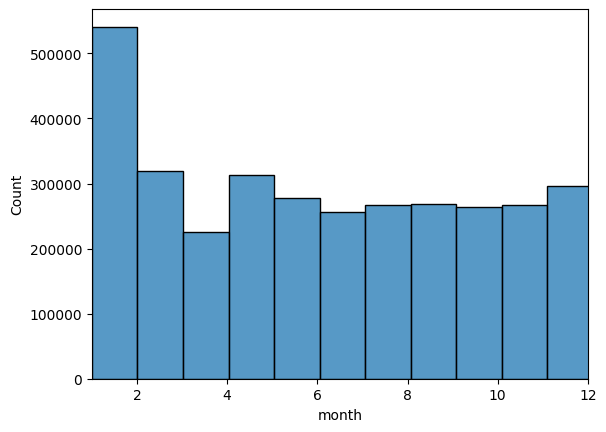

In [6]:
sns.histplot(combined_cloud_df, x="month",binwidth=1.01)
plt.xlim(1,12)

Size distribution all vs glaciating 

In [7]:
total_north = combined_cloud_df[(combined_cloud_df["min_temp"]<-10) & (combined_cloud_df["min_temp"]>-31) & (combined_cloud_df["Hemisphere"]=="North") & (combined_cloud_df["max_water_frac"]>0.4)]["is_glaciating"].mean()

In [8]:
total_south = combined_cloud_df[(combined_cloud_df["min_temp"]<-10)& (combined_cloud_df["min_temp"]>-31)  & (combined_cloud_df["Hemisphere"]=="South") & (combined_cloud_df["max_water_frac"]>0.4)]["is_glaciating"].mean()

In [9]:

north_list=[]
south_list=[]
for month in range(1,13):
    north_list.append(combined_cloud_df[(combined_cloud_df["month"]==month) & (combined_cloud_df["min_temp"]<-10) & (combined_cloud_df["Hemisphere"]=="North") & (combined_cloud_df["max_water_frac"]>0.4)]["is_glaciating"].mean())
    south_list.append(combined_cloud_df[(combined_cloud_df["month"]==month) & (combined_cloud_df["min_temp"]<-10) & (combined_cloud_df["Hemisphere"]=="South") & (combined_cloud_df["max_water_frac"]>0.4)]["is_glaciating"].mean())

In [10]:
print(total_north*100)
print(total_south*100)
print((total_north-total_south)*100)
print(total_north/total_south*100-100)

3.4719348340455953
3.2267582261662464
0.24517660787934867
7.598232984770178


In [11]:
print(np.std(north_list))
print(np.std(south_list))

0.010985228695900507
0.010745180642000605


/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


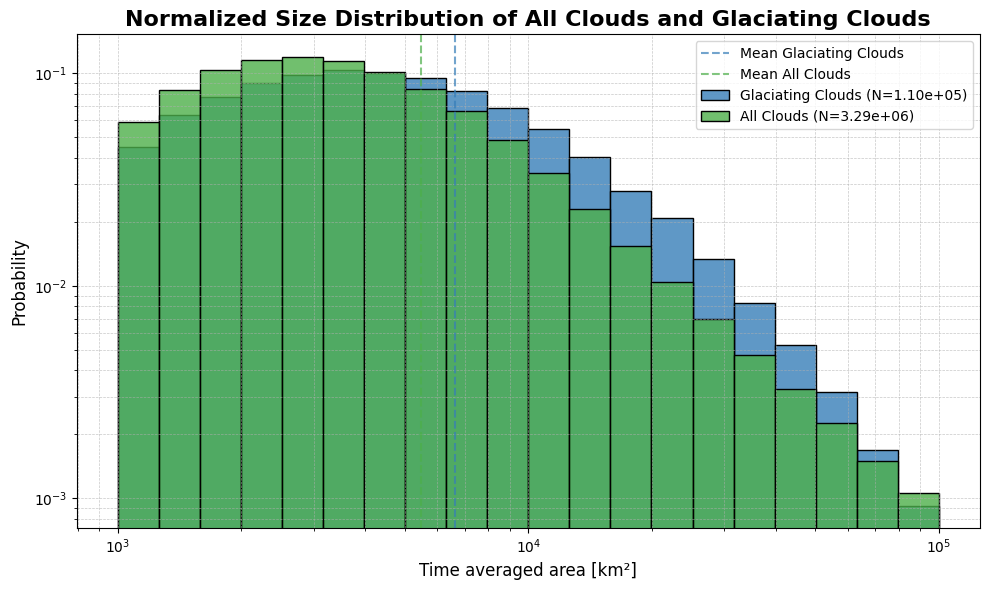

In [ ]:
# Assuming `glaciating_clouds` and `combined_cloud_df` are preloaded DataFrames
mean_glaciating = glaciating_clouds['avg_size[km]'].mean()
mean_combined = combined_cloud_df['avg_size[km]'].mean()

f, ax = plt.subplots(figsize=(12, 6))  # Increased figure size for better readability

# Plot histograms
sns.histplot(
    data=glaciating_clouds,
    ax=ax,
    x="avg_size[km]",
    log_scale=(True, False),
    binrange=(3, 5),
    bins=20,
    color=classifiacation_palette[1],
    stat="probability",
    label=f"Glaciating Clouds (N={len(glaciating_clouds):.2e})",
    alpha=0.8  # Slight transparency for overlap visibility
)

sns.histplot(
    data=combined_cloud_df,
    ax=ax,
    x="avg_size[km]",
    log_scale=(True, False),
    binrange=(3, 5),
    bins=20,
    color=classifiacation_palette[2],
    stat="probability",
    label=f"All Clouds (N={len(combined_cloud_df):.2e})",
    alpha=0.8
)

# Add vertical lines for means
ax.axvline(mean_glaciating, linestyle="--", color=classifiacation_palette[1], linewidth=1.5, alpha=0.7, label="Mean Glaciating Clouds")
ax.axvline(mean_combined, color=classifiacation_palette[2], linestyle="--", linewidth=1.5, alpha=0.7, label="Mean All Clouds")

# Set logarithmic y-axis
ax.set_yscale("log")

# Beautify the plot
ax.set_title("Normalized Size Distribution of All Clouds and Glaciating Clouds", fontsize=16, weight="bold")
ax.set_xlabel("Time averaged area [km²]", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()

# Save the figure
filename = os.path.join(GTE_DIR,f"Result_graphs/Size_hist_all_vs_glac_normalized")
plt.savefig(filename + ".pdf", dpi=400, bbox_inches='tight')
plt.savefig(filename + ".png", dpi=400, bbox_inches='tight')

Glaciation occurance rate with temperature

In [13]:
monthly_rate = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
for n_month in range(1, 13):
    print(n_month)
    glac_month_kernel = (
        glaciating_clouds['track_start_time'].dt.month == n_month)
    comb_month_kernel = (
        combined_cloud_df['track_start_time'].dt.month == n_month)
    if glac_month_kernel.sum() != 0:
        occurrence_rate = (
            glaciating_clouds[glac_month_kernel]["min_temp"].value_counts(sort=False) /
            combined_cloud_df[comb_month_kernel]["min_temp"].value_counts(
                sort=False) * 100
        )
        monthly_rate.loc[n_month, occurrence_rate.index] = occurrence_rate.values
    else:
        monthly_rate.loc[n_month] = 0
monthly_rate = monthly_rate.fillna(0)

1
2
3
4
5
6
7
8
9
10
11
12


/tmp/ipykernel_12195/1165283523.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_rate = monthly_rate.fillna(0)


In [14]:
error_occ=[]
for min_temp in combined_cloud_df["min_temp"].unique():
    ser = monthly_rate[min_temp]
    uppper_quantile_value = ser.quantile(q=0.75)
    lower_quantile_value= ser.quantile(q=0.25)
    error_occ.append(ser[(ser>lower_quantile_value) & (ser<uppper_quantile_value)].std())
error_occ = error_occ[::-1]

In [ ]:
glac

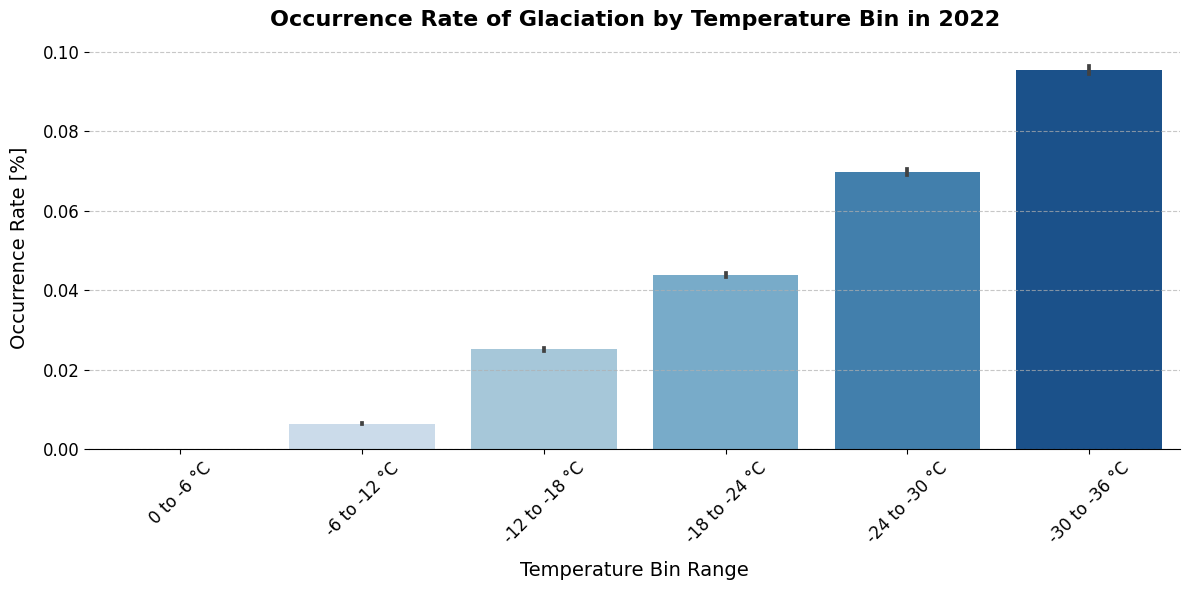

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Calculate occurrence rate
occurrence_rate = glaciating_clouds["min_temp"].value_counts(sort=False) / combined_cloud_df["min_temp"].value_counts(sort=False) * 100


# Create bin ranges
bin_ranges = [f"{int(temp)+6} to {int(temp)} °C" for temp in occurrence_rate.index]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data = combined_cloud_df, x="min_temp",
                 y='is_glaciating',
                 palette=temperature_palette[::-1], label=bin_ranges)  # Disable default error bars
# Customize grid
ax.set_xticklabels(bin_ranges,fontsize=12, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Labeling
plt.xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
plt.ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
plt.title("Occurrence Rate of Glaciation by Temperature Bin in 2022", fontsize=16, fontweight="bold", pad=15)
# plt.xticks()
plt.yticks(fontsize=12)

# Invert x-axis
plt.gca().invert_xaxis()

# # Remove spines except for the vertical one (left spine)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# # Save and show plot
plt.tight_layout()
# plt.savefig(os.path.join(GTE_DIR, "Result_graphs/Glaciation_occurance_rates.png"), dpi=400)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Calculate occurrence rate
occurrence_rate = glaciating_clouds["min_temp"].value_counts(sort=False) / combined_cloud_df["min_temp"].value_counts(sort=False) * 100

# Create bin ranges
bin_ranges = [f"{int(temp)+6} to {int(temp)} °C" for temp in occurrence_rate.index]

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=bin_ranges,
                 y=occurrence_rate.values,
                 palette=temperature_palette[::-1],
                 ci=None)  # Disable default error bars

# Add custom error bars
ax.errorbar(x=np.arange(len(bin_ranges)), 
            y=occurrence_rate.values, 
            yerr=error_occ, 
            fmt='none',       # No markers
            capsize=5,        # Cap size for error bars
            color='black',
            alpha=0.7)    # Error bar color

# Customize grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Labeling
plt.xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
plt.ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
plt.title("Occurrence Rate of Glaciation by Temperature Bin in 2022", fontsize=16,fontweight="bold", pad=15)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

# Invert x-axis
plt.gca().invert_xaxis()

# Remove spines except for the vertical one (left spine)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(GTE_DIR, "Result_graphs/Glaciation_occurance_rates.png"), dpi=400, bbox_inches='tight')
plt.show()


Occurance rate by hemisphere 

In [17]:
# daily_rate_north = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
# monthly_rate_south = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
# northern_glac_kernel = (glaciating_clouds["Hemisphere"] == "North")
# southern_glac_kernel = (glaciating_clouds["Hemisphere"] == "South")
# northern_comb_kernel = (combined_cloud_df["Hemisphere"] == "North")
# southern_comb_kernel = (combined_cloud_df["Hemisphere"] == "South")
# for n_day in range(1, 366):
#     print(n_day)
#     glac_day_kernel = (
#         glaciating_clouds['track_start_time'].dt.dayofyear == n_day)
#     comb_day_kernel = (
#         combined_cloud_df['track_start_time'].dt.dayofyear == n_day)
#     if glac_day_kernel.sum() != 0:
#         occurrence_rate_north = (
#             glaciating_clouds[northern_glac_kernel & glac_day_kernel]["min_temp"].value_counts(sort=False) /
#             combined_cloud_df[northern_comb_kernel & comb_day_kernel]["min_temp"].value_counts(
#                 sort=False) * 100
#         )
#         occurrence_rate_south = (
#             glaciating_clouds[southern_glac_kernel & glac_day_kernel]["min_temp"].value_counts(sort=False) /
#             combined_cloud_df[southern_comb_kernel & comb_day_kernel]["min_temp"].value_counts(
#                 sort=False) * 100
#         )
#         daily_rate_north.loc[n_day, occurrence_rate_north.index] = occurrence_rate_north.values
#         daily_rate_south.loc[n_day, occurrence_rate_south.index] = occurrence_rate_south.values
#     else:
#         daily_rate_north.loc[n_day] = 0
#         daily_rate_south.loc[n_day] = 0
# daily_rate_north = daily_rate_north.fillna(0)
# daily_rate_south = daily_rate_south.fillna(0)

In [18]:
monthly_rate_north = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
monthly_rate_south = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
monthly_difference = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
northern_glac_kernel = (glaciating_clouds["Hemisphere"] == "North" )&( glaciating_clouds["max_water_frac"] > 0.4)
southern_glac_kernel = (glaciating_clouds["Hemisphere"] == "South") &( glaciating_clouds["max_water_frac"] > 0.4)
northern_comb_kernel = (combined_cloud_df["Hemisphere"] == "North") &( combined_cloud_df["max_water_frac"] > 0.4)
southern_comb_kernel = (combined_cloud_df["Hemisphere"] == "South") &( combined_cloud_df["max_water_frac"] > 0.4)
for n_day in range(1, 13):
    print(n_day)
    glac_day_kernel = (
        glaciating_clouds['track_start_time'].dt.month == n_day)
    comb_day_kernel = (
        combined_cloud_df['track_start_time'].dt.month == n_day)
    if glac_day_kernel.sum() != 0:
        occurrence_rate_north = (
            glaciating_clouds[northern_glac_kernel & glac_day_kernel]["min_temp"].value_counts(sort=False) /
            combined_cloud_df[northern_comb_kernel & comb_day_kernel]["min_temp"].value_counts(
                sort=False) * 100
        )
        occurrence_rate_south = (
            glaciating_clouds[southern_glac_kernel & glac_day_kernel]["min_temp"].value_counts(sort=False) /
            combined_cloud_df[southern_comb_kernel & comb_day_kernel]["min_temp"].value_counts(
                sort=False) * 100
        )
        monthly_rate_north.loc[n_day, occurrence_rate_north.index] = occurrence_rate_north.values
        monthly_rate_south.loc[n_day, occurrence_rate_south.index] = occurrence_rate_south.values
        monthly_difference.loc[n_day, occurrence_rate_south.index] = occurrence_rate_north - occurrence_rate_south
    else:
        monthly_rate_north.loc[n_day] = 0
        monthly_rate_south.loc[n_day] = 0
monthly_rate_north = monthly_rate_north.fillna(0)
monthly_rate_south = monthly_rate_south.fillna(0)
monthly_difference = monthly_difference.fillna(0)



1
2
3
4
5
6
7
8
9
10
11
12


/tmp/ipykernel_12195/4025935125.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_rate_north = monthly_rate_north.fillna(0)
/tmp/ipykernel_12195/4025935125.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_rate_south = monthly_rate_south.fillna(0)
/tmp/ipykernel_12195/4025935125.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcast

In [19]:
def calculate_seasonal_val(months, monthly_rate_north, monthly_rate_south ):
    print(f"Months: {(monthly_rate_north.quantile(0.75)- monthly_rate_north.quantile(0.25))/2} {monthly_rate_north.loc[months].std()}")
    return monthly_rate_north.loc[months].std().values, monthly_rate_south.loc[months].std().values
    

Months: -6     0.000000
-12    0.326809
-18    1.408914
-24    2.108550
-30    2.249132
-36    2.637664
dtype: float64 -6     0.000000
-12    0.441634
-18    1.585304
-24    2.469344
-30    2.808141
-36    4.974563
dtype: float64


/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

Months: -6     0.000000
-12    0.326809
-18    1.408914
-24    2.108550
-30    2.249132
-36    2.637664
dtype: float64 -6     0.000000
-12    0.314003
-18    0.298231
-24    0.244569
-30    1.201302
-36    0.329519
dtype: float64
Months: -6     0.000000
-12    0.326809
-18    1.408914
-24    2.108550
-30    2.249132
-36    2.637664
dtype: float64 -6     0.000000
-12    0.014870
-18    0.119761
-24    0.579338
-30    1.384785
-36    1.570621
dtype: float64
Months: -6     0.000000
-12    0.326809
-18    1.408914
-24    2.108550
-30    2.249132
-36    2.637664
dtype: float64 -6     0.000000
-12    0.325585
-18    1.398392
-24    1.959521
-30    1.710938
-36    0.301401
dtype: float64
Months: -6     0.000000
-12    0.326809
-18    1.408914
-24    2.108550
-30    2.249132
-36    2.637664
dtype: float64 -6     0.000000
-12    0.190416
-18    0.983328
-24    1.206469
-30    1.286064
-36    2.650391
dtype: float64


/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


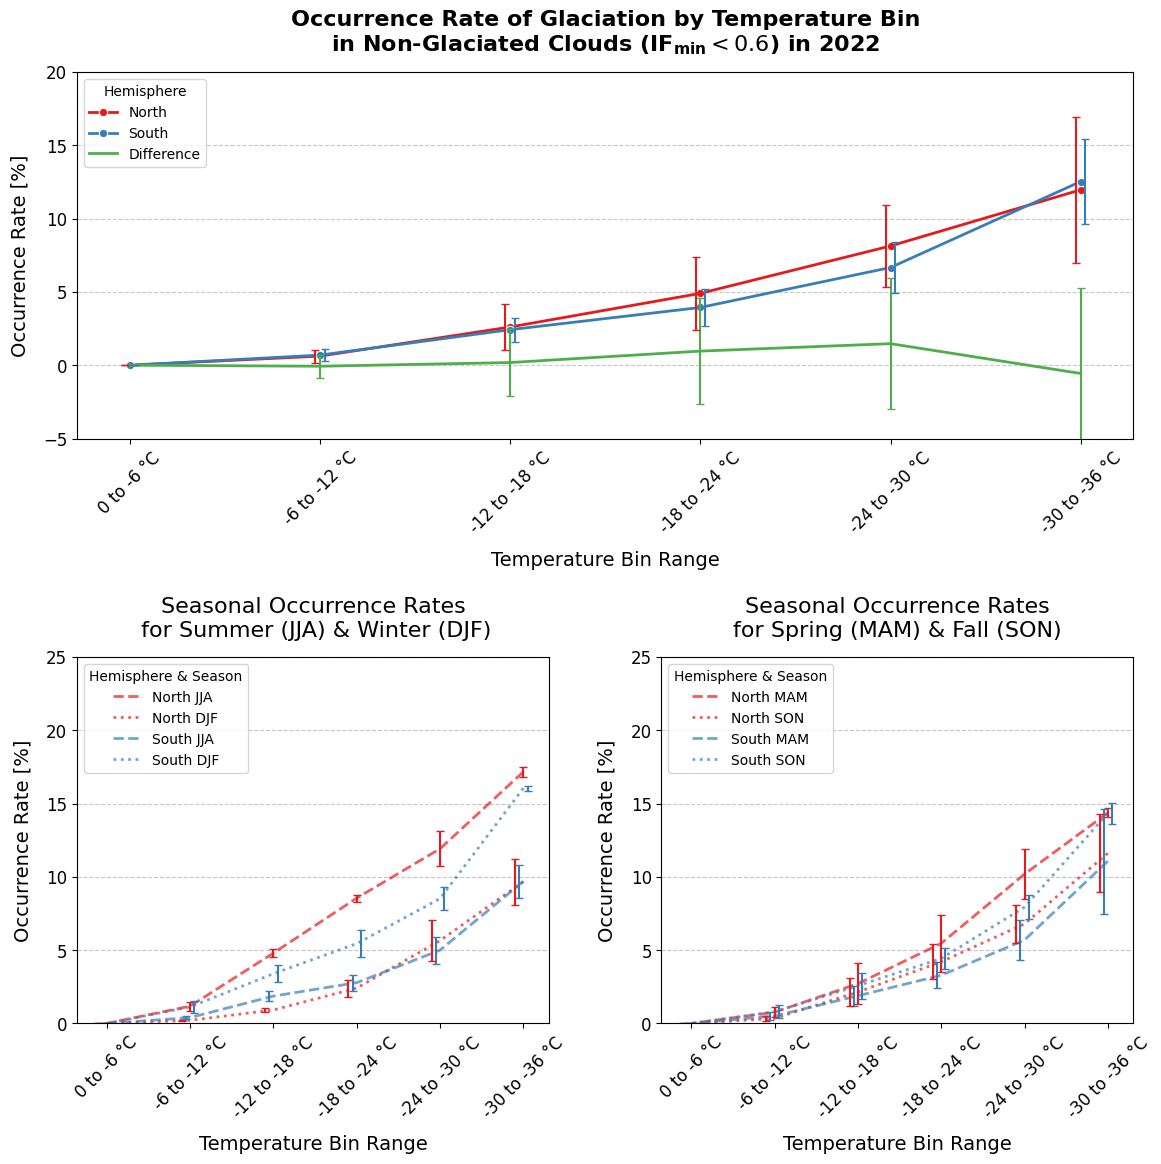

In [20]:
error_np,error_sp = calculate_seasonal_val(np.arange(1,13), monthly_rate_north, monthly_rate_south )
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Assuming glaciating_clouds, combined_cloud_df, classifiacation_palette, GTE_DIR,
# monthly_rate_north, and monthly_rate_south are already defined

# Define season-specific kernels
summer_glac_kernel = glaciating_clouds["Season"] == "JJA"
summer_comb_kernel = combined_cloud_df["Season"] == "JJA"

winter_glac_kernel = glaciating_clouds["Season"] == "DJF"
winter_comb_kernel = combined_cloud_df["Season"] == "DJF"

spring_glac_kernel = glaciating_clouds["Season"] == "MAM"
spring_comb_kernel = combined_cloud_df["Season"] == "MAM"

fall_glac_kernel = glaciating_clouds["Season"] == "SON"
fall_comb_kernel = combined_cloud_df["Season"] == "SON"

# Define hemisphere kernels
northern_glac_kernel = (glaciating_clouds["Hemisphere"] == "North") & (glaciating_clouds["max_water_frac"] > 0.4)
southern_glac_kernel = (glaciating_clouds["Hemisphere"] == "South") & (glaciating_clouds["max_water_frac"] > 0.4)
northern_comb_kernel = (combined_cloud_df["Hemisphere"] == "North") & (combined_cloud_df["max_water_frac"] > 0.4)
southern_comb_kernel = (combined_cloud_df["Hemisphere"] == "South") & (combined_cloud_df["max_water_frac"] > 0.4)

# Calculate overall occurrence rates
occurrence_rate_north = (
    glaciating_clouds[northern_glac_kernel]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south = (
    glaciating_clouds[southern_glac_kernel]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

# Calculate seasonal occurrence rates for JJA and DJF
occurrence_rate_north_summer = (
    glaciating_clouds[(northern_glac_kernel) & (summer_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & summer_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_summer = (
    glaciating_clouds[(southern_glac_kernel) & (summer_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & summer_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

occurrence_rate_north_winter = (
    glaciating_clouds[(northern_glac_kernel) & (winter_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & winter_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_winter = (
    glaciating_clouds[(southern_glac_kernel) & (winter_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & winter_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

# Calculate seasonal occurrence rates for MAM and SON
occurrence_rate_north_spring = (
    glaciating_clouds[(northern_glac_kernel) & (spring_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & spring_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_spring = (
    glaciating_clouds[(southern_glac_kernel) & (spring_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & spring_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

occurrence_rate_north_fall = (
    glaciating_clouds[(northern_glac_kernel) & (fall_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & fall_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_fall = (
    glaciating_clouds[(southern_glac_kernel) & (fall_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & fall_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

# Replace NaN values with 0
occurrence_rate_north = occurrence_rate_north.fillna(0)
occurrence_rate_south = occurrence_rate_south.fillna(0)
occurrence_rate_north_summer = occurrence_rate_north_summer.fillna(0)
occurrence_rate_south_summer = occurrence_rate_south_summer.fillna(0)
occurrence_rate_north_winter = occurrence_rate_north_winter.fillna(0)
occurrence_rate_south_winter = occurrence_rate_south_winter.fillna(0)
occurrence_rate_north_spring = occurrence_rate_north_spring.fillna(0)
occurrence_rate_south_spring = occurrence_rate_south_spring.fillna(0)
occurrence_rate_north_fall = occurrence_rate_north_fall.fillna(0)
occurrence_rate_south_fall = occurrence_rate_south_fall.fillna(0)

# Create bin ranges for the x-axis
bin_ranges = [f"{int(temp+6)} to {int(temp)} °C" for temp in occurrence_rate_north.index]
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Remove the previous plt.subplots call and use GridSpec for a consistent layout:
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# Top subplot: spans the entire first row
ax1 = fig.add_subplot(gs[0, :])
# Bottom subplots: left and right of the second row
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])


# Define x positions for error bars (as before)
x_pos_pos = np.arange(len(bin_ranges)) + 0.05
x_pos_pos_2 = np.arange(len(bin_ranges)) + 0.10
x_pos_neg = np.arange(len(bin_ranges)) - 0.05

# --- Plot 1: Overall Occurrence Rates ---
sns.lineplot(x=bin_ranges, y=occurrence_rate_north.values, ax=ax1, label="North", 
             color=classifiacation_palette[0], marker='o', linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south.values, ax=ax1, label="South", 
             color=classifiacation_palette[1], marker='o', linewidth=2)

sns.lineplot(x=bin_ranges, y= occurrence_rate_north.values - occurrence_rate_south.values, ax=ax1, label="Difference", 
             color=classifiacation_palette[2], markers=True, linewidth=2)

ax1.errorbar(bin_ranges, occurrence_rate_north.values - occurrence_rate_south.values, yerr=monthly_difference.std().to_list()[::-1], 
             color=classifiacation_palette[2], capsize=3, linestyle='')
# Example error bars (ensure error_np and error_sp are defined appropriately)
ax1.errorbar(x_pos_pos-0.025, occurrence_rate_north.values, yerr=error_np[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax1.errorbar(x_pos_neg+0.025, occurrence_rate_south.values, yerr=error_sp[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')
ax1.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title("Occurrence Rate of Glaciation by Temperature Bin\nin Non-Glaciated Clouds ($\\mathregular{IF_{min}}<0.6$) in 2022", fontsize=16, pad=15,fontweight="bold")
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.invert_xaxis()
ax1.legend(title="Hemisphere")

# --- Plot 2: Seasonal Occurrence Rates (Summer & Winter) ---
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_summer.values, ax=ax2, label="North JJA", 
             color=classifiacation_palette[0], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_winter.values, ax=ax2, label="North DJF", 
             color=classifiacation_palette[0], linestyle=":", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_summer.values, ax=ax2, label="South JJA", 
             color=classifiacation_palette[1], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_winter.values, ax=ax2, label="South DJF", 
             color=classifiacation_palette[1], linestyle=":", alpha=0.7, linewidth=2)

# Error bars for summer
error_np_summer, error_sp_summer = calculate_seasonal_val([6, 7, 8], monthly_rate_north, monthly_rate_south)
ax2.errorbar(bin_ranges, occurrence_rate_north_summer.values, yerr=error_np_summer[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax2.errorbar(x_pos_pos, occurrence_rate_south_summer.values, yerr=error_sp_summer[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

# Error bars for winter (DJF)
error_np_winter, error_sp_winter = calculate_seasonal_val([12, 1, 2], monthly_rate_north, monthly_rate_south)
ax2.errorbar(x_pos_pos_2, occurrence_rate_north_winter.values, yerr=error_np_winter[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax2.errorbar(x_pos_neg, occurrence_rate_south_winter.values, yerr=error_sp_winter[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\n for Summer (JJA) & Winter (DJF)", fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.invert_xaxis()
ax2.legend(title="Hemisphere & Season", loc="upper left")

# --- Plot 3: Seasonal Occurrence Rates (Spring & Fall) ---
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_spring.values, ax=ax3, label="North MAM", 
             color=classifiacation_palette[0], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_fall.values, ax=ax3, label="North SON", 
             color=classifiacation_palette[0], linestyle=":", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_spring.values, ax=ax3, label="South MAM", 
             color=classifiacation_palette[1], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_fall.values, ax=ax3, label="South SON", 
             color=classifiacation_palette[1], linestyle=":", alpha=0.7, linewidth=2)

# Error bars for spring (MAM)
error_np_spring, error_sp_spring = calculate_seasonal_val([3, 5], monthly_rate_north, monthly_rate_south)
ax3.errorbar(bin_ranges, occurrence_rate_north_spring.values, yerr=error_np_spring[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax3.errorbar(x_pos_pos, occurrence_rate_south_spring.values, yerr=error_sp_spring[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

# Error bars for fall (SON)
error_np_fall, error_sp_fall = calculate_seasonal_val([9, 10, 11], monthly_rate_north, monthly_rate_south)
ax3.errorbar(x_pos_pos_2, occurrence_rate_north_fall.values, yerr=error_np_fall[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax3.errorbar(x_pos_neg, occurrence_rate_south_fall.values, yerr=error_sp_fall[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)", fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.invert_xaxis()
ax3.legend(title="Hemisphere & Season", loc="upper left")

# Use tight_layout to ensure that titles and labels do not overlap
plt.tight_layout(pad=2.0)

# Save the overall figure
plt.savefig(os.path.join(GTE_DIR, "Result_graphs/Glaciation_occurance_rates_normalized_to_Ice_Clouds_by_pole_and_spring_vs_autumn.png"), dpi=400, bbox_inches='tight')
plt.show()



/tmp/ipykernel_12195/2461213027.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.lineplot(combined_cloud_df, x="min_temp", y="is_glaciating", hue="Hemisphere",palette=classifiacation_palette,errorbar=("ci", 99),marker='o')
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 

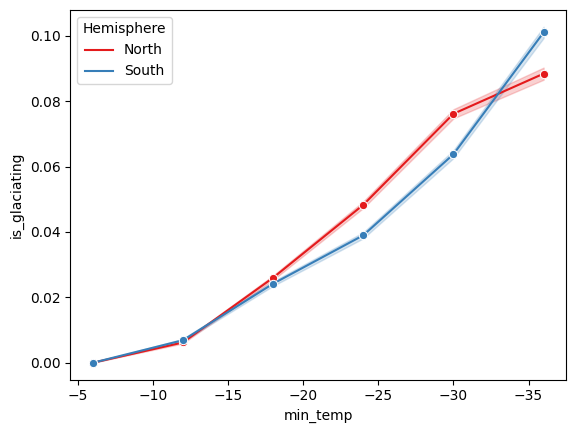

In [21]:

ax = sns.lineplot(combined_cloud_df, x="min_temp", y="is_glaciating", hue="Hemisphere",palette=classifiacation_palette,errorbar=("ci", 99),marker='o')
ax.invert_xaxis()

In [22]:
monthly_rate_north = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
monthly_rate_south = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
monthly_difference = pd.DataFrame(columns=combined_cloud_df["min_temp"].unique())
northern_glac_kernel = (glaciating_clouds["Hemisphere"] == "North")
southern_glac_kernel = (glaciating_clouds["Hemisphere"] == "South")
northern_comb_kernel = (combined_cloud_df["Hemisphere"] == "North")
southern_comb_kernel = (combined_cloud_df["Hemisphere"] == "South")
for n_day in range(1, 13):
    print(n_day)
    glac_day_kernel = (
        glaciating_clouds['track_start_time'].dt.month == n_day)
    comb_day_kernel = (
        combined_cloud_df['track_start_time'].dt.month == n_day)
    if glac_day_kernel.sum() != 0:
        occurrence_rate_north = (
            glaciating_clouds[northern_glac_kernel & glac_day_kernel]["min_temp"].value_counts(sort=False) /
            combined_cloud_df[northern_comb_kernel & comb_day_kernel]["min_temp"].value_counts(
                sort=False) * 100
        )
        occurrence_rate_south = (
            glaciating_clouds[southern_glac_kernel & glac_day_kernel]["min_temp"].value_counts(sort=False) /
            combined_cloud_df[southern_comb_kernel & comb_day_kernel]["min_temp"].value_counts(
                sort=False) * 100
        )
        monthly_rate_north.loc[n_day, occurrence_rate_north.index] = occurrence_rate_north.values
        monthly_rate_south.loc[n_day, occurrence_rate_south.index] = occurrence_rate_south.values
        monthly_difference.loc[n_day, occurrence_rate_south.index] = occurrence_rate_north - occurrence_rate_south
    else:
        monthly_rate_north.loc[n_day] = 0
        monthly_rate_south.loc[n_day] = 0
monthly_rate_north = monthly_rate_north.fillna(0)
monthly_rate_south = monthly_rate_south.fillna(0)
monthly_difference = monthly_difference.fillna(0)

1
2
3
4
5
6
7
8
9
10
11
12


/tmp/ipykernel_12195/2790471101.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_rate_north = monthly_rate_north.fillna(0)
/tmp/ipykernel_12195/2790471101.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_rate_south = monthly_rate_south.fillna(0)
/tmp/ipykernel_12195/2790471101.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcast

Months: -6     0.000000
-12    0.326786
-18    1.399696
-24    2.015172
-30    1.991247
-36    0.935034
dtype: float64 -6     0.000000
-12    0.441606
-18    1.572511
-24    2.339133
-30    2.326453
-36    2.901377
dtype: float64


/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

Months: -6     0.000000
-12    0.326786
-18    1.399696
-24    2.015172
-30    1.991247
-36    0.935034
dtype: float64 -6     0.000000
-12    0.313991
-18    0.307163
-24    0.350610
-30    1.068454
-36    0.806120
dtype: float64
Months: -6     0.000000
-12    0.326786
-18    1.399696
-24    2.015172
-30    1.991247
-36    0.935034
dtype: float64 -6     0.000000
-12    0.014868
-18    0.119678
-24    0.578220
-30    1.359221
-36    1.140907
dtype: float64


/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

Months: -6     0.000000
-12    0.326786
-18    1.399696
-24    2.015172
-30    1.991247
-36    0.935034
dtype: float64 -6     0.000000
-12    0.325595
-18    1.393119
-24    1.894702
-30    1.255134
-36    0.849866
dtype: float64
Months: -6     0.000000
-12    0.326786
-18    1.399696
-24    2.015172
-30    1.991247
-36    0.935034
dtype: float64 -6     0.000000
-12    0.190407
-18    0.978199
-24    1.136038
-30    1.142962
-36    1.602165
dtype: float64


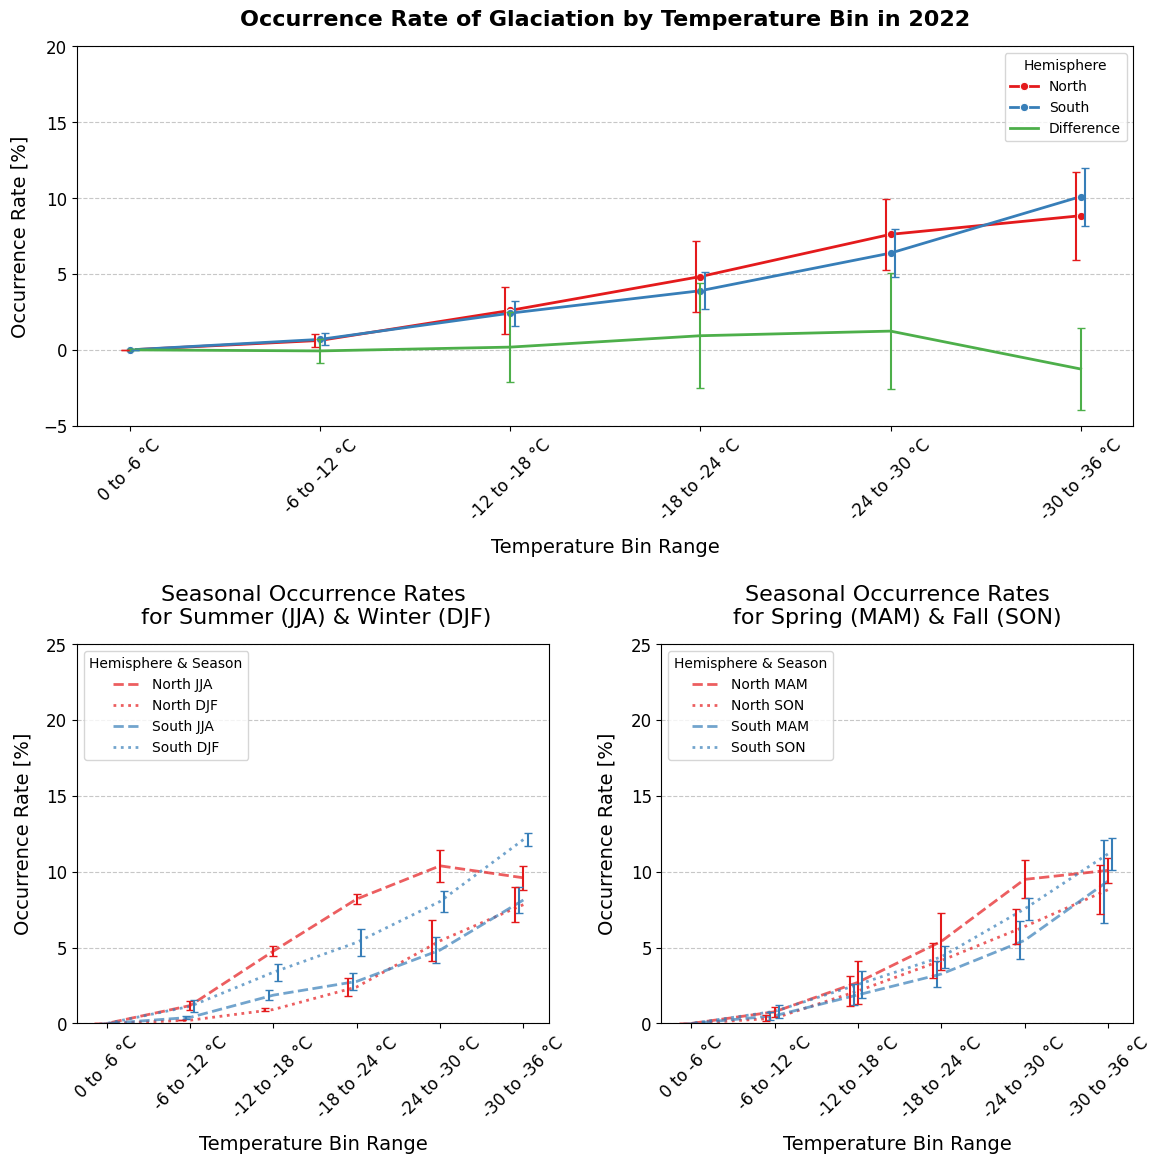

In [23]:
error_np,error_sp = calculate_seasonal_val(np.arange(1,13), monthly_rate_north, monthly_rate_south )
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Assuming glaciating_clouds, combined_cloud_df, classifiacation_palette, GTE_DIR,
# monthly_rate_north, and monthly_rate_south are already defined

# Define season-specific kernels
summer_glac_kernel = glaciating_clouds["Season"] == "JJA"
summer_comb_kernel = combined_cloud_df["Season"] == "JJA"

winter_glac_kernel = glaciating_clouds["Season"] == "DJF"
winter_comb_kernel = combined_cloud_df["Season"] == "DJF"

spring_glac_kernel = glaciating_clouds["Season"] == "MAM"
spring_comb_kernel = combined_cloud_df["Season"] == "MAM"

fall_glac_kernel = glaciating_clouds["Season"] == "SON"
fall_comb_kernel = combined_cloud_df["Season"] == "SON"

# Define hemisphere kernels
northern_glac_kernel = (glaciating_clouds["Hemisphere"] == "North")
southern_glac_kernel = (glaciating_clouds["Hemisphere"] == "South")
northern_comb_kernel = (combined_cloud_df["Hemisphere"] == "North")
southern_comb_kernel = (combined_cloud_df["Hemisphere"] == "South")

# Calculate overall occurrence rates
occurrence_rate_north = (
    glaciating_clouds[northern_glac_kernel]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south = (
    glaciating_clouds[southern_glac_kernel]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

# Calculate seasonal occurrence rates for JJA and DJF
occurrence_rate_north_summer = (
    glaciating_clouds[(northern_glac_kernel) & (summer_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & summer_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_summer = (
    glaciating_clouds[(southern_glac_kernel) & (summer_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & summer_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

occurrence_rate_north_winter = (
    glaciating_clouds[(northern_glac_kernel) & (winter_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & winter_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_winter = (
    glaciating_clouds[(southern_glac_kernel) & (winter_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & winter_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

# Calculate seasonal occurrence rates for MAM and SON
occurrence_rate_north_spring = (
    glaciating_clouds[(northern_glac_kernel) & (spring_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & spring_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_spring = (
    glaciating_clouds[(southern_glac_kernel) & (spring_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & spring_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

occurrence_rate_north_fall = (
    glaciating_clouds[(northern_glac_kernel) & (fall_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[northern_comb_kernel & fall_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)
occurrence_rate_south_fall = (
    glaciating_clouds[(southern_glac_kernel) & (fall_glac_kernel)]["min_temp"].value_counts(sort=False) /
    combined_cloud_df[southern_comb_kernel & fall_comb_kernel]["min_temp"].value_counts(sort=False) * 100
)

# Replace NaN values with 0
occurrence_rate_north = occurrence_rate_north.fillna(0)
occurrence_rate_south = occurrence_rate_south.fillna(0)
occurrence_rate_north_summer = occurrence_rate_north_summer.fillna(0)
occurrence_rate_south_summer = occurrence_rate_south_summer.fillna(0)
occurrence_rate_north_winter = occurrence_rate_north_winter.fillna(0)
occurrence_rate_south_winter = occurrence_rate_south_winter.fillna(0)
occurrence_rate_north_spring = occurrence_rate_north_spring.fillna(0)
occurrence_rate_south_spring = occurrence_rate_south_spring.fillna(0)
occurrence_rate_north_fall = occurrence_rate_north_fall.fillna(0)
occurrence_rate_south_fall = occurrence_rate_south_fall.fillna(0)

# Create bin ranges for the x-axis
bin_ranges = [f"{int(temp+6)} to {int(temp)} °C" for temp in occurrence_rate_north.index]
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Remove the previous plt.subplots call and use GridSpec for a consistent layout:
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# Top subplot: spans the entire first row
ax1 = fig.add_subplot(gs[0, :])
# Bottom subplots: left and right of the second row
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])


# Define x positions for error bars (as before)
x_pos_pos = np.arange(len(bin_ranges)) + 0.05
x_pos_pos_2 = np.arange(len(bin_ranges)) + 0.10
x_pos_neg = np.arange(len(bin_ranges)) - 0.05

# --- Plot 1: Overall Occurrence Rates ---
sns.lineplot(x=bin_ranges, y=occurrence_rate_north.values, ax=ax1, label="North", 
             color=classifiacation_palette[0], marker='o', linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south.values, ax=ax1, label="South", 
             color=classifiacation_palette[1], marker='o', linewidth=2)

sns.lineplot(x=bin_ranges, y= occurrence_rate_north.values - occurrence_rate_south.values, ax=ax1, label="Difference", 
             color=classifiacation_palette[2], markers=True, linewidth=2)

ax1.errorbar(bin_ranges, occurrence_rate_north.values - occurrence_rate_south.values, yerr=monthly_difference.std().to_list()[::-1], 
             color=classifiacation_palette[2], capsize=3, linestyle='')
# Example error bars (ensure error_np and error_sp are defined appropriately)
ax1.errorbar(x_pos_pos-0.025, occurrence_rate_north.values, yerr=error_np[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax1.errorbar(x_pos_neg+0.025, occurrence_rate_south.values, yerr=error_sp[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')
ax1.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title("Occurrence Rate of Glaciation by Temperature Bin in 2022", fontsize=16, pad=15,fontweight="bold")
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.invert_xaxis()
ax1.legend(title="Hemisphere")

# --- Plot 2: Seasonal Occurrence Rates (Summer & Winter) ---
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_summer.values, ax=ax2, label="North JJA", 
             color=classifiacation_palette[0], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_winter.values, ax=ax2, label="North DJF", 
             color=classifiacation_palette[0], linestyle=":", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_summer.values, ax=ax2, label="South JJA", 
             color=classifiacation_palette[1], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_winter.values, ax=ax2, label="South DJF", 
             color=classifiacation_palette[1], linestyle=":", alpha=0.7, linewidth=2)

# Error bars for summer
error_np_summer, error_sp_summer = calculate_seasonal_val([6, 7, 8], monthly_rate_north, monthly_rate_south)
ax2.errorbar(bin_ranges, occurrence_rate_north_summer.values, yerr=error_np_summer[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax2.errorbar(x_pos_pos, occurrence_rate_south_summer.values, yerr=error_sp_summer[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

# Error bars for winter (DJF)
error_np_winter, error_sp_winter = calculate_seasonal_val([12, 1, 2], monthly_rate_north, monthly_rate_south)
ax2.errorbar(x_pos_pos_2, occurrence_rate_north_winter.values, yerr=error_np_winter[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax2.errorbar(x_pos_neg, occurrence_rate_south_winter.values, yerr=error_sp_winter[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\n for Summer (JJA) & Winter (DJF)", fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.invert_xaxis()
ax2.legend(title="Hemisphere & Season", loc="upper left")

# --- Plot 3: Seasonal Occurrence Rates (Spring & Fall) ---
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_spring.values, ax=ax3, label="North MAM", 
             color=classifiacation_palette[0], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_north_fall.values, ax=ax3, label="North SON", 
             color=classifiacation_palette[0], linestyle=":", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_spring.values, ax=ax3, label="South MAM", 
             color=classifiacation_palette[1], linestyle="--", alpha=0.7, linewidth=2)
sns.lineplot(x=bin_ranges, y=occurrence_rate_south_fall.values, ax=ax3, label="South SON", 
             color=classifiacation_palette[1], linestyle=":", alpha=0.7, linewidth=2)

# Error bars for spring (MAM)
error_np_spring, error_sp_spring = calculate_seasonal_val([3, 5], monthly_rate_north, monthly_rate_south)
ax3.errorbar(bin_ranges, occurrence_rate_north_spring.values, yerr=error_np_spring[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax3.errorbar(x_pos_pos, occurrence_rate_south_spring.values, yerr=error_sp_spring[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

# Error bars for fall (SON)
error_np_fall, error_sp_fall = calculate_seasonal_val([9, 10, 11], monthly_rate_north, monthly_rate_south)
ax3.errorbar(x_pos_pos_2, occurrence_rate_north_fall.values, yerr=error_np_fall[::-1], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax3.errorbar(x_pos_neg, occurrence_rate_south_fall.values, yerr=error_sp_fall[::-1], 
             color=classifiacation_palette[1], capsize=3, linestyle='')

ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)", fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.invert_xaxis()
ax3.legend(title="Hemisphere & Season", loc="upper left")

# Use tight_layout to ensure that titles and labels do not overlap
plt.tight_layout(pad=2.0)

# Save the overall figure
plt.savefig(os.path.join(GTE_DIR, "Result_graphs/Glaciation_occurance_rates_by_pole_and_spring_vs_autumn.png"), dpi=400, bbox_inches='tight')
plt.show()